## Q.2 Building Markov transition matrix
You have learned important differences between simple dinucleotide frequency model and Markov models. Your goal is to build one from the input sequence. In the Jupyter notebook, you should print the transition matrix.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Input DNA sequence
seq = "ACGTTGCAACACACGTCAGAATGCATAATACGTCCTTTATGCCGGAAGACACAGATACGATACAGAT"

# Initialize transition frequency
NUCLEOTIDES = ['A', 'C', 'G', 'T']
TRANSITION_FREQ = {i: {j: 0 for j in NUCLEOTIDES} for i in NUCLEOTIDES}

# Count transitions
for i in range(len(seq) - 1):
    curr = seq[i]
    next = seq[i + 1]
    
    if curr in NUCLEOTIDES and next in NUCLEOTIDES:
        TRANSITION_FREQ[curr][next] += 1
    else :
        print(f"Invalid nucleotide found: {curr} or {next}.")

# Normalize to get probabilities
TRANSITION_MAT = {i: {} for i in NUCLEOTIDES}
for i in NUCLEOTIDES:
    total = sum(TRANSITION_FREQ[i].values())
    for j in NUCLEOTIDES:
        if total > 0:
            TRANSITION_MAT[i][j] = TRANSITION_FREQ[i][j] / total
        else:
            TRANSITION_MAT[i][j] = 0.0

# Print the transition matrix
df = pd.DataFrame(TRANSITION_MAT)
print("Transition Matrix:")
print(df)

Transition Matrix:
          A       C         G         T
A  0.166667  0.5000  0.461538  0.384615
C  0.375000  0.1250  0.230769  0.153846
G  0.166667  0.3125  0.076923  0.230769
T  0.291667  0.0625  0.230769  0.230769


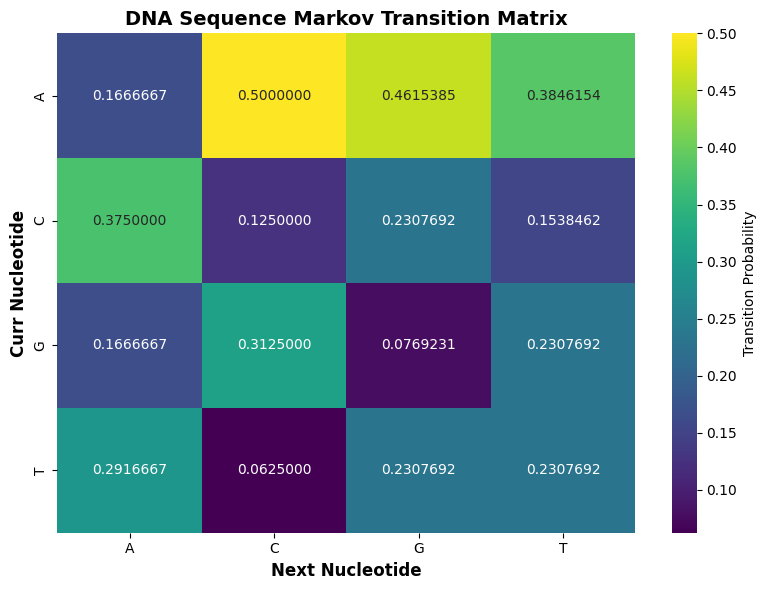

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".7f", cmap="viridis", cbar_kws={"label": "Transition Probability"})
plt.xlabel("Next Nucleotide",  fontsize=12, fontweight="bold")
plt.ylabel("Curr Nucleotide", fontsize=12, fontweight="bold")
plt.title("DNA Sequence Markov Transition Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
total = len(seq) - 1
# compute frequencies from transition frequency
FREQ_PAIRS = {
    f"{i}{j}": TRANSITION_FREQ[i][j] / total
    for i in NUCLEOTIDES
    for j in NUCLEOTIDES
}

pairs = sorted(FREQ_PAIRS.keys())
freqs = [FREQ_PAIRS[p] for p in pairs]

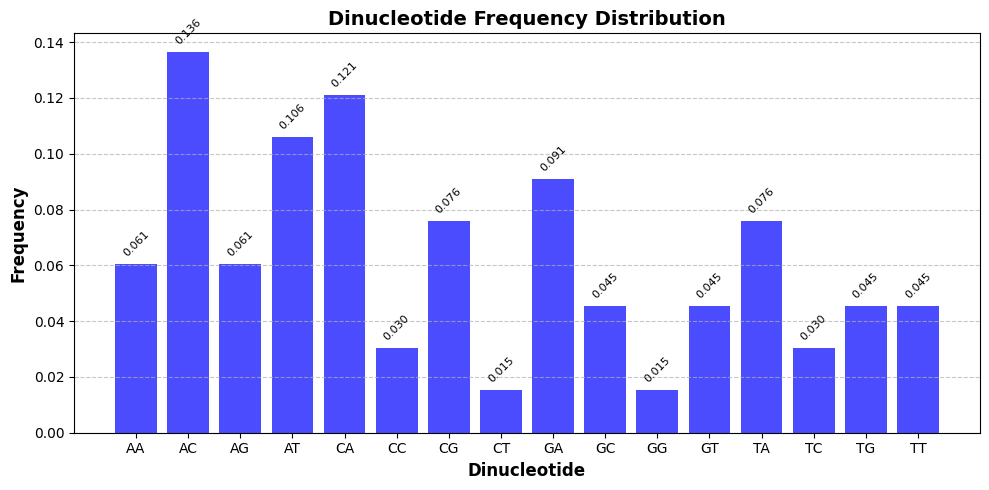

In [10]:
plt.figure(figsize=(10, 5))
bars = plt.bar(pairs, freqs, color="blue", alpha=0.7)
plt.xlabel("Dinucleotide", fontsize=12, fontweight="bold")
plt.ylabel("Frequency",    fontsize=12, fontweight="bold")
plt.title("Dinucleotide Frequency Distribution", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Annotate each bar with its value
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.002, f"{h:.3f}", ha="center", va="bottom", rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation of the Matrix

The transition matrix shows the probability of moving from one nucleotide (rows) to another (columns). 

For example:
- The value at position [0,1] represents P(C|A) - the probability of observing a C after an A.
- The value at position [2,3] represents P(T|G) - the probability of observing a T after a G.

### Difference Between Dinucleotide Frequency and Markov Models

1. **Dinucleotide Frequency Model**: Simply counts the occurrences of each possible dinucleotide (AA, AC, AG, AT, CA, etc.) and normalizes by the total number of dinucleotides in the sequence.

2. **First-order Markov Model**: Represents the conditional probability of each nucleotide given the previous one. It captures the dependency between adjacent nucleotides in a sequence.

The key difference is that a Markov model provides transition probabilities that are conditional on the current state, whereas a dinucleotide frequency model simply provides joint probabilities of consecutive nucleotides.